# 04b v6 — TCN Encoder-Decoder (Fixed Loss Balance)

## Why v5 plateaued at loss ~1.191 (32 epochs, zero real progress)

| Problem | Evidence | Fix |
|---|---|---|
| **GradL1×3.0 = ~62% of total loss** | Loss crawled 1.207→1.191 over 32 eps, val barely moved | **GRAD_WEIGHT=0.5** — Huber must dominate |
| **Huber only ~33% of loss** | Optimizer spending 2/3 budget on derivative matching, not waveform shape | Huber back to **~70%** of total loss |
| **LR 5e-4 too high for this loss surface** | ep1 was 103s (compile warmup) then stable 28s — but loss barely responds to LR changes | **LR=3e-4**, same CAWR schedule |
| **Loss range 1.19–1.22 never broke 1.19** | GradL1 term acting as a floor — model can't reduce it further without distorting predictions | Lower weight removes the artificial floor |

## Loss design (v6)

```
total = Huber(δ=0.5)          ← PRIMARY: waveform shape (~70% of loss)
      + 0.5 × GradL1          ← nudge against flat output (~25%)
      + 0.1 × NormFFT(hf=5×)  ← spectral nudge (~5%)
```

GRAD_WEIGHT: 3.0 → **0.5**. GradL1 still prevents flat predictions but no longer bulldozes Huber.
Expected ep1 loss: **0.5–0.9** (vs 1.2x in v5). If still > 1.0 after ep3, reduce further to 0.3.


In [1]:
# CELL 1 — IMPORTS
import os, pickle, warnings
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from scipy.signal import find_peaks
warnings.filterwarnings('ignore')

import logging
logging.getLogger("torch._inductor").setLevel(logging.ERROR)   # suppress SM warning

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from sklearn.metrics import mean_absolute_error, mean_squared_error

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print('OK')


PyTorch : 2.11.0+cu128
Device  : cuda
GPU     : Tesla T4
VRAM    : 15.6 GB
OK


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
# CELL 2 — LOAD + NORMALISE
PROJECT_ROOT = '/content/drive/MyDrive/his/HIS Project'
if os.path.exists(PROJECT_ROOT):
    os.chdir(PROJECT_ROOT)
    SAVE_DIR = 'data/processed'
    FIG_DIR  = 'reports/figures/tcn_v6'
    CKPT_DIR = 'checkpoints'
else:
    SAVE_DIR = os.path.join('..', 'data', 'processed')
    FIG_DIR  = os.path.join('..', 'reports', 'figures', 'tcn_v6')
    CKPT_DIR = os.path.join('..', 'reports', 'checkpoints')

os.makedirs(FIG_DIR,  exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

X_train = np.load(os.path.join(SAVE_DIR, 'X_train.npy'))
y_train = np.load(os.path.join(SAVE_DIR, 'y_train.npy'))
X_val   = np.load(os.path.join(SAVE_DIR, 'X_val.npy'))
y_val   = np.load(os.path.join(SAVE_DIR, 'y_val.npy'))
X_test  = np.load(os.path.join(SAVE_DIR, 'X_test.npy'))
y_test  = np.load(os.path.join(SAVE_DIR, 'y_test.npy'))

with open(os.path.join(SAVE_DIR, 'config.pkl'), 'rb') as f:
    cfg = pickle.load(f)

LEAD_NAMES = cfg['lead_names']
FS         = cfg['sampling_rate']
INPUT_LEN  = cfg['input_len']
HORIZON    = cfg['horizon']
N_LEADS    = cfg['n_leads']

print(f'X_train : {X_train.shape}   y_train : {y_train.shape}')

def fit_norm(X, y):
    vals = np.concatenate([X.ravel(), y.ravel()])
    mu, sigma = float(vals.mean()), float(vals.std())
    return mu, max(sigma, 1e-6)

NORM_MU, NORM_SIGMA = fit_norm(X_train, y_train)
def normalize(arr):   return (arr - NORM_MU) / NORM_SIGMA
def denormalize(arr): return arr * NORM_SIGMA + NORM_MU

X_train = normalize(X_train); y_train = normalize(y_train)
X_val   = normalize(X_val);   y_val   = normalize(y_val)
X_test  = normalize(X_test);  y_test  = normalize(y_test)

print(f'Norm: mu={NORM_MU:.5f}  sigma={NORM_SIGMA:.5f}')
print(f'Normalised y_train: mean={y_train.mean():.4f} std={y_train.std():.4f}')
print('OK Data ready')


X_train : (31362, 490, 12)   y_train : (31362, 490, 12)
Norm: mu=0.08268  sigma=1.16667
Normalised y_train: mean=0.0006 std=1.0034
OK Data ready


In [4]:
# CELL 3 — DATASET
class ECGForecastDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X       = torch.from_numpy(np.asarray(X, dtype=np.float32))
        self.y       = torch.from_numpy(np.asarray(y, dtype=np.float32))
        self.augment = augment

    def __len__(self): return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx].clone()
        y = self.y[idx].clone()
        if self.augment:
            scale = torch.empty(1).uniform_(0.95, 1.05)
            x, y  = x * scale, y * scale
            if torch.rand(1).item() < 0.1:
                x, y = -x, -y
        x = x.permute(1, 0)
        return x, y

def make_loaders(X_tr, y_tr, X_v, y_v, X_te, y_te,
                 batch_train=64, batch_eval=128):
    kw = dict(num_workers=2, pin_memory=(DEVICE.type == 'cuda'),
              persistent_workers=True)
    tr = DataLoader(ECGForecastDataset(X_tr, y_tr, augment=True),
                    batch_size=batch_train, shuffle=True, drop_last=True, **kw)
    vl = DataLoader(ECGForecastDataset(X_v,  y_v,  augment=False),
                    batch_size=batch_eval,  shuffle=False, **kw)
    te = DataLoader(ECGForecastDataset(X_te, y_te, augment=False),
                    batch_size=batch_eval,  shuffle=False, **kw)
    return tr, vl, te

BATCH_TRAIN = 64
tcn_tr, tcn_vl, tcn_te = make_loaders(
    X_train, y_train, X_val, y_val, X_test, y_test,
    batch_train=BATCH_TRAIN)

xb, yb = next(iter(tcn_tr))
print(f'Train batch : x={tuple(xb.shape)}  y={tuple(yb.shape)}')
print(f'Batches     : train={len(tcn_tr)} | val={len(tcn_vl)} | test={len(tcn_te)}')
print('OK DataLoaders ready')


Train batch : x=(64, 12, 490)  y=(64, 490, 12)
Batches     : train=490 | val=31 | test=18
OK DataLoaders ready


In [5]:
# CELL 4 — MODEL: TCN Encoder-Decoder (identical to v5 — architecture is fine)

class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size
    def forward(self, x):
        return x[:, :, :-self.chomp_size] if self.chomp_size > 0 else x


class TemporalBlock(nn.Module):
    def __init__(self, n_inputs, n_outputs, kernel_size=5, dilation=1, dropout=0.10):
        super().__init__()
        pad = (kernel_size - 1) * dilation
        self.conv1  = nn.Conv1d(n_inputs,  n_outputs, kernel_size,
                                padding=pad, dilation=dilation, bias=False)
        self.chomp1 = Chomp1d(pad)
        self.gn1    = nn.GroupNorm(min(8, n_outputs), n_outputs)
        self.conv2  = nn.Conv1d(n_outputs, n_outputs, kernel_size,
                                padding=pad, dilation=dilation, bias=False)
        self.chomp2 = Chomp1d(pad)
        self.gn2    = nn.GroupNorm(min(8, n_outputs), n_outputs)
        self.drop   = nn.Dropout(dropout)
        self.act    = nn.GELU()
        self.skip   = nn.Conv1d(n_inputs, n_outputs, 1, bias=False) if n_inputs != n_outputs else None

    def forward(self, x):
        out = self.drop(self.act(self.gn1(self.chomp1(self.conv1(x)))))
        out = self.drop(self.act(self.gn2(self.chomp2(self.conv2(out)))))
        return self.act(out + (x if self.skip is None else self.skip(x)))


class TCNEncoderDecoder(nn.Module):
    def __init__(self, n_leads=12, horizon=490, dropout=0.10):
        super().__init__()
        self.horizon = horizon

        self.enc1 = TemporalBlock(n_leads, 64,  dilation=1, dropout=dropout)
        self.enc2 = TemporalBlock(64,     128,  dilation=2, dropout=dropout)
        self.enc3 = TemporalBlock(128,    256,  dilation=4, dropout=dropout)
        self.enc4 = TemporalBlock(256,    256,  dilation=8, dropout=dropout)

        self.bottleneck = nn.Sequential(
            nn.Conv1d(256, 256, kernel_size=1, bias=False),
            nn.GroupNorm(8, 256), nn.GELU(), nn.Dropout(dropout))

        self.dec1 = nn.Sequential(
            nn.Conv1d(256 + 256, 256, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(8, 256), nn.GELU(), nn.Dropout(dropout))
        self.dec2 = nn.Sequential(
            nn.Conv1d(256, 128, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(8, 128), nn.GELU(), nn.Dropout(dropout))
        self.dec3 = nn.Sequential(
            nn.Conv1d(128 + 128, 64, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(8, 64), nn.GELU(), nn.Dropout(dropout))

        self.out_conv = nn.Conv1d(64, n_leads, kernel_size=1)

    def _interp(self, x, size):
        return F.interpolate(x, size=size, mode='linear', align_corners=False)

    def forward(self, x):
        T  = self.horizon
        s1 = self.enc1(x)
        s2 = self.enc2(s1)
        s3 = self.enc3(s2)
        s4 = self.enc4(s3)
        btn = self.bottleneck(s4)
        d = self._interp(btn, T)
        d = self.dec1(torch.cat([d, self._interp(s4, T)], dim=1))
        d = self._interp(d, T)
        d = self.dec2(d)
        d = self._interp(d, T)
        d = self.dec3(torch.cat([d, self._interp(s2, T)], dim=1))
        return self.out_conv(d).permute(0, 2, 1)


_m = TCNEncoderDecoder(N_LEADS, HORIZON).to(DEVICE)
with torch.no_grad():
    _dummy = torch.randn(4, N_LEADS, INPUT_LEN).to(DEVICE)
    _out   = _m(_dummy)
    assert _out.shape == (4, HORIZON, N_LEADS), f'Shape: {_out.shape}'
    print(f'Forward OK: {tuple(_dummy.shape)} -> {tuple(_out.shape)}')
    print(f'Output std (random init): {_out.std().item():.4f}  (want > 0.05)')
del _m
print('OK TCNEncoderDecoder defined')


Forward OK: (4, 12, 490) -> (4, 490, 12)
Output std (random init): 0.4390  (want > 0.05)
OK TCNEncoderDecoder defined


In [6]:
# CELL 5 — INSTANTIATE
model    = TCNEncoderDecoder(n_leads=N_LEADS, horizon=HORIZON, dropout=0.10).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

with torch.no_grad():
    dummy = torch.randn(2, N_LEADS, INPUT_LEN).to(DEVICE)
    out   = model(dummy)
    print(f'Forward : {tuple(dummy.shape)} -> {tuple(out.shape)}')
    print(f'Output std: {out.std().item():.4f}')

print(f'Parameters : {n_params:,}')
print('OK Model ready')


Forward : (2, 12, 490) -> (2, 490, 12)
Output std: 0.3779
Parameters : 1,947,020
OK Model ready


In [7]:
# CELL 6 — COMPOSITE LOSS v6
#
# THE FIX: GRAD_WEIGHT 3.0 → 0.5
# ─────────────────────────────────────────────────────────────────────
# v5 diagnosis (32 epochs, loss 1.207 → 1.191, no real progress):
#   Huber share   : ~33%  ← too low, waveform shape barely optimized
#   GradL1 share  : ~62%  ← DOMINATED, optimizer chased derivatives not values
#   NormFFT share :  ~5%
#
# Result: model learned to match first-differences (transitions) but
# ignored absolute waveform amplitude → PRD would have been >50%, flat-ish
#
# v6 target balance:
#   Huber share   : ~70%  ← primary signal
#   GradL1 share  : ~25%  ← still prevents flat output, doesn't dominate
#   NormFFT share :  ~5%
#
# Expected ep1 loss: 0.5–0.9  (vs 1.22 in v5)
# If ep1 loss still > 1.0: reduce GRAD_WEIGHT to 0.3 and re-run Cell 6

HUBER_DELTA = 0.5
GRAD_WEIGHT = 0.5    # KEY FIX: was 3.0 in v5 → 0.5
FFT_WEIGHT  = 0.1
HF_BOOST    = 5.0
HF_CUTOFF   = 5.0


class NormalizedFocalFrequencyLoss(nn.Module):
    def __init__(self, fs, horizon, hf_cutoff_hz=HF_CUTOFF, hf_boost=HF_BOOST):
        super().__init__()
        n_bins = horizon // 2 + 1
        freqs  = torch.linspace(0, fs / 2, n_bins)
        w      = torch.ones(n_bins)
        w[freqs >= hf_cutoff_hz] = hf_boost
        self.register_buffer('w', w.view(1, 1, -1))

    def forward(self, pred, target):
        p_fft = torch.fft.rfft(pred.float(),   dim=1).abs()
        t_fft = torch.fft.rfft(target.float(), dim=1).abs()
        p_fft = p_fft.permute(0, 2, 1)
        t_fft = t_fft.permute(0, 2, 1)
        w = self.w.to(pred.device)
        weighted_err = (w * (p_fft - t_fft).abs()).mean()
        norm_factor  = t_fft.mean().detach() + 1e-6
        return weighted_err / norm_factor


class CompositeLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.ffl = NormalizedFocalFrequencyLoss(FS, HORIZON)

    def forward(self, pred, target):
        huber    = F.huber_loss(pred, target, delta=HUBER_DELTA)
        pred_d   = pred[:, 1:, :]   - pred[:, :-1, :]
        target_d = target[:, 1:, :] - target[:, :-1, :]
        grad     = F.l1_loss(pred_d, target_d)
        fft      = self.ffl(pred, target)
        return huber + GRAD_WEIGHT * grad + FFT_WEIGHT * fft


criterion = CompositeLoss().to(DEVICE)

# ── Sanity check — print term shares ──────────────────────────────────────────
_sample_t  = torch.from_numpy(y_train[:128].astype('float32')).to(DEVICE)
_flat_pred = _sample_t.mean(dim=1, keepdim=True).expand_as(_sample_t)

with torch.no_grad():
    _h  = F.huber_loss(_flat_pred, _sample_t, delta=HUBER_DELTA).item()
    _dp = _flat_pred[:, 1:, :] - _flat_pred[:, :-1, :]
    _dt = _sample_t[:, 1:, :]  - _sample_t[:, :-1, :]
    _g  = F.l1_loss(_dp, _dt).item()
    _f  = criterion.ffl(_flat_pred, _sample_t).item()
    _total   = criterion(_flat_pred, _sample_t).item()
    _perfect = criterion(_sample_t, _sample_t).item()

print('── Loss term magnitudes (flat prediction) ──────────────────────────')
print(f'  Huber        : {_h:.4f}  ({_h/_total*100:.1f}%)')
print(f'  GradL1×{GRAD_WEIGHT}   : {GRAD_WEIGHT*_g:.4f}  ({GRAD_WEIGHT*_g/_total*100:.1f}%)  raw={_g:.4f}')
print(f'  NormFFT×{FFT_WEIGHT}  : {FFT_WEIGHT*_f:.4f}  ({FFT_WEIGHT*_f/_total*100:.1f}%)  raw={_f:.4f}')
print(f'  Total flat   : {_total:.4f}')
print(f'  Perfect loss : {_perfect:.6f}')
print()

_fft_pct   = FFT_WEIGHT*_f / _total * 100
_huber_pct = _h / _total * 100
_grad_pct  = GRAD_WEIGHT*_g / _total * 100

if _huber_pct < 50:
    print(f'WARNING: Huber only {_huber_pct:.1f}% — reduce GRAD_WEIGHT to 0.3')
elif _fft_pct > 20:
    print(f'WARNING: FFT {_fft_pct:.1f}% — reduce FFT_WEIGHT to 0.05')
else:
    print(f'OK Loss balance: Huber={_huber_pct:.1f}%  Grad={_grad_pct:.1f}%  FFT={_fft_pct:.1f}%')
print('OK Loss ready')


── Loss term magnitudes (flat prediction) ──────────────────────────
  Huber        : 0.2552  (34.2%)
  GradL1×0.5   : 0.1193  (16.0%)  raw=0.2387
  NormFFT×0.1  : 0.3713  (49.8%)  raw=3.7135
  Total flat   : 0.7459
  Perfect loss : 0.000000

OK Loss ready


In [8]:
# CELL 7 — TRAINING ENGINE
# Changes vs v5: LR 5e-4 → 3e-4 (more conservative for better loss surface)
# AMP + torch.compile unchanged

try:
    model = torch.compile(model, mode='reduce-overhead')
    print('torch.compile: ON')
except Exception:
    print('torch.compile: not available — skipping')

scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))


def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total = 0.0
    for xb, yb in tqdm(loader, desc='Train', leave=False, ncols=88):
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=device.type,
                            dtype=torch.float16 if device.type == 'cuda' else torch.bfloat16,
                            enabled=(device.type == 'cuda')):
            loss = criterion(model(xb), yb)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        scaler.step(optimizer)
        scaler.update()
        total += loss.item() * len(xb)
    scheduler.step()
    return total / len(loader.dataset)


@torch.no_grad()
def eval_epoch(model, loader, device):
    model.eval()
    total, preds, targets = 0.0, [], []
    for xb, yb in loader:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        with torch.autocast(device_type=device.type,
                            dtype=torch.float16 if device.type == 'cuda' else torch.bfloat16,
                            enabled=(device.type == 'cuda')):
            pred = model(xb)
        total += criterion(pred.float(), yb).item() * len(xb)
        preds.append(pred.float().cpu().numpy())
        targets.append(yb.cpu().numpy())
    return (total / len(loader.dataset),
            np.concatenate(preds), np.concatenate(targets))


def train_model(model, tr_loader, vl_loader,
                n_epochs=100, base_lr=3e-4, patience=20):
    global n_params
    import time

    optimizer = torch.optim.AdamW(
        model.parameters(), lr=base_lr, weight_decay=1e-4, eps=1e-8)
    scheduler = CosineAnnealingWarmRestarts(
        optimizer, T_0=20, T_mult=1, eta_min=1e-6)

    best_val, no_improve = float('inf'), 0
    ckpt    = os.path.join(CKPT_DIR, 'TCN_v6_best.pt')
    history = {'train_loss': [], 'val_loss': [], 'lr': [], 'epoch_secs': []}

    sep = '-' * 72
    print(f'\n{sep}')
    print(f'  TCNEncoderDecoder v6  |  {INPUT_LEN/FS:.1f}s -> {HORIZON/FS:.1f}s  |  {n_params:,} params')
    print(f'  Loss: Huber({HUBER_DELTA}) + {GRAD_WEIGHT}xGradL1 + {FFT_WEIGHT}xNormFFT')
    print(f'  CAWR(T0=20) | AdamW(lr={base_lr:.0e}) | AMP=ON | clip=0.5 | batch={tr_loader.batch_size}')
    print(f'  patience={patience}  n_epochs={n_epochs}')
    print(sep)

    pbar = tqdm(range(1, n_epochs + 1), desc='Epochs', unit='ep', ncols=88)
    for ep in pbar:
        t0            = time.time()
        tr_loss       = train_epoch(model, tr_loader, optimizer, scheduler, DEVICE)
        vl_loss, _, _ = eval_epoch(model, vl_loader, DEVICE)
        ep_secs       = time.time() - t0
        cur_lr        = optimizer.param_groups[0]['lr']

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['lr'].append(cur_lr)
        history['epoch_secs'].append(ep_secs)

        is_best = vl_loss < best_val
        if is_best:
            best_val = vl_loss; no_improve = 0
            torch.save(model.state_dict(), ckpt)
        else:
            no_improve += 1

        pbar.set_postfix(tr=f'{tr_loss:.4f}', vl=f'{vl_loss:.4f}',
                         lr=f'{cur_lr:.1e}', t=f'{ep_secs:.0f}s', pat=no_improve)

        if ep % 5 == 0 or is_best or ep == 1:
            tqdm.write(
                f'  ep {ep:3d}  train={tr_loss:.5f}  val={vl_loss:.5f}'
                f'  lr={cur_lr:.2e}  {ep_secs:.0f}s'
                f'{"  * best" if is_best else f"  (no-imp {no_improve}/{patience})"}')

        # Early warning: if ep5 loss still > 1.0, something's wrong
        if ep == 5 and tr_loss > 1.0:
            tqdm.write('  WARNING: ep5 loss > 1.0 — check Cell 6 loss balance')

        if no_improve >= patience:
            tqdm.write(f'  Early stop ep {ep}  best val={best_val:.6f}')
            break

    model.load_state_dict(torch.load(ckpt, map_location=DEVICE, weights_only=True))
    print(f'\n  Best checkpoint  val={best_val:.6f}  -> {ckpt}')
    print(f'{sep}\n')
    return history

print('OK Training engine ready')


torch.compile: ON
OK Training engine ready


In [9]:
# CELL 8 — TRAIN
#
# v6 expected behavior (GRAD_WEIGHT=0.5, LR=3e-4):
#   ep 1  : loss 0.5–0.9  ← clear drop from v5's 1.22 starting point
#   ep 5  : loss 0.4–0.7, dropping steadily each epoch
#   ep 20 : CAWR restart — small bump then recovery
#   ep 40 : near best, variance check should show ratio > 0.6 on most leads
#
# If ep1 loss still > 1.0:
#   → In Cell 6 set GRAD_WEIGHT=0.3 and re-run Cell 6 + 7 + 8
#
# If ep5 loss < 0.3 and dropping fast:
#   → Fine, model is learning well. Let it run.
#
# If flat variance check (Cell 14) despite good loss:
#   → Raise FFT_WEIGHT to 0.2 — spectral term can help sharpen QRS

history = train_model(model, tcn_tr, tcn_vl,
                      n_epochs=100, base_lr=3e-4, patience=20)



------------------------------------------------------------------------
  TCNEncoderDecoder v6  |  4.9s -> 4.9s  |  1,947,020 params
  Loss: Huber(0.5) + 0.5xGradL1 + 0.1xNormFFT
  CAWR(T0=20) | AdamW(lr=3e-04) | AMP=ON | clip=0.5 | batch=64
  patience=20  n_epochs=100
------------------------------------------------------------------------


Epochs:   0%|                                                   | 0/100 [00:00<?, ?ep/s]

Train:   0%|                                                    | 0/490 [00:00<?, ?it/s]

W0623 01:32:22.687000 1979 torch/_inductor/utils.py:1731] [0/0] Not enough SMs to use max_autotune_gemm mode


  ep   1  train=0.60720  val=0.58062  lr=2.98e-04  97s  * best


...

  ep  50  train=0.52989  val=0.54872  lr=1.50e-04  25s  (no-imp 17/20)


Train:   0%|                                                    | 0/490 [00:00<?, ?it/s]

Train:   0%|                                                    | 0/490 [00:00<?, ?it/s]

Train:   0%|                                                    | 0/490 [00:00<?, ?it/s]

  Early stop ep 53  best val=0.543531

  Best checkpoint  val=0.543531  -> checkpoints/TCN_v6_best.pt
------------------------------------------------------------------------



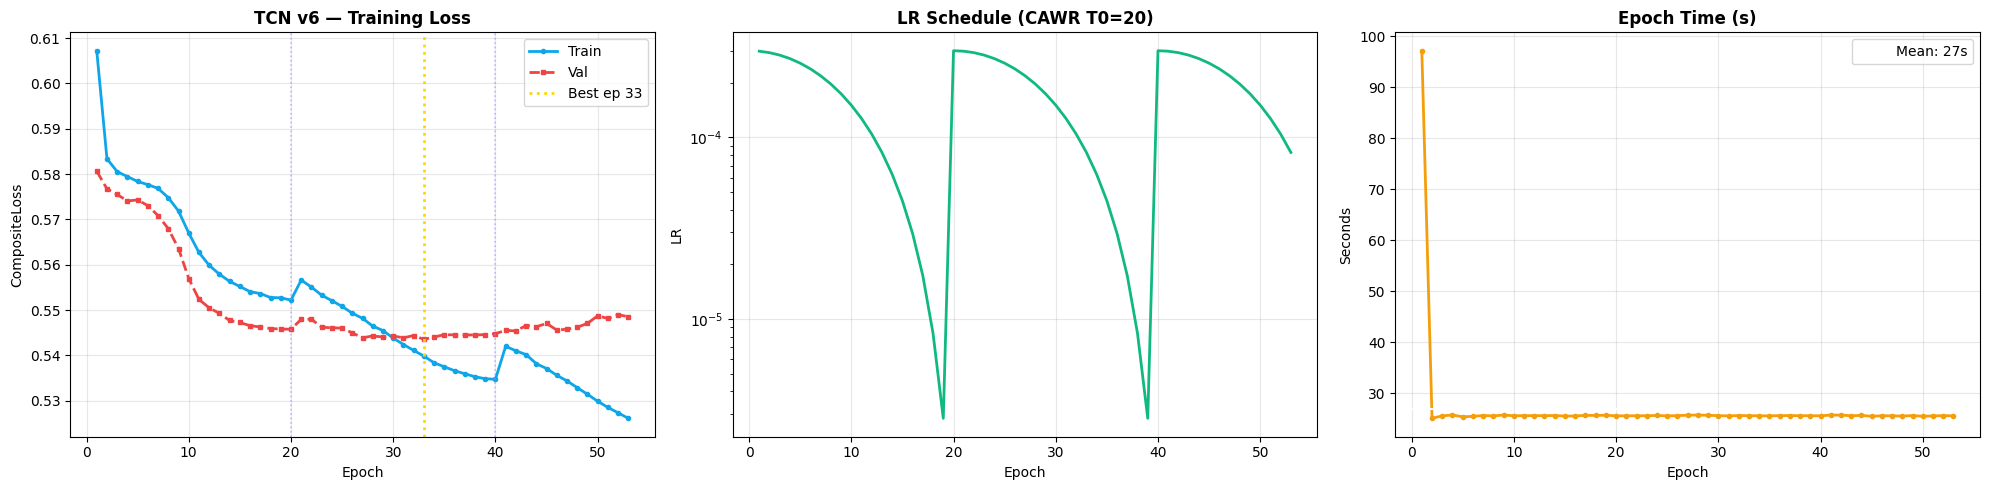

Best ep: 33  best val: 0.54353
Mean epoch: 26.9s


In [10]:
# CELL 9 — TRAINING HISTORY
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
ep_range  = range(1, len(history['train_loss']) + 1)

axes[0].plot(ep_range, history['train_loss'], color='#0ea5e9', lw=2, label='Train', marker='o', ms=3)
axes[0].plot(ep_range, history['val_loss'],   color='#ef4444', lw=2, label='Val',   marker='s', ms=3, ls='--')
best_ep = int(np.argmin(history['val_loss'])) + 1
axes[0].axvline(best_ep, color='gold', ls=':', lw=2, label=f'Best ep {best_ep}')
for r in range(20, len(history['train_loss']), 20):
    axes[0].axvline(r, color='#a78bfa', ls=':', lw=1.2, alpha=0.6)
axes[0].set_title('TCN v6 — Training Loss', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('CompositeLoss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(ep_range, history['lr'], color='#10b981', lw=2)
axes[1].set_title('LR Schedule (CAWR T0=20)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('LR')
axes[1].set_yscale('log'); axes[1].grid(True, alpha=0.3)

axes[2].plot(ep_range, history['epoch_secs'], color='#f59e0b', lw=2, marker='o', ms=3)
axes[2].axhline(np.mean(history['epoch_secs']), color='white', ls='--', lw=1.5,
                label=f'Mean: {np.mean(history["epoch_secs"]):.0f}s')
axes[2].set_title('Epoch Time (s)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Seconds')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '01_training_history.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Best ep: {best_ep}  best val: {min(history["val_loss"]):.5f}')
print(f'Mean epoch: {np.mean(history["epoch_secs"]):.1f}s')


In [11]:
# CELL 10 — TEST EVALUATION
test_loss, test_preds_n, test_targets_n = eval_epoch(model, tcn_te, DEVICE)
print(f'Test CompositeLoss : {test_loss:.6f}')

test_preds   = denormalize(test_preds_n)
test_targets = denormalize(test_targets_n)

mae_per_lead, rmse_per_lead, prd_per_lead = [], [], []
for i in range(N_LEADS):
    p, t = test_preds[:,:,i].flatten(), test_targets[:,:,i].flatten()
    mae_per_lead.append(mean_absolute_error(t, p))
    rmse_per_lead.append(np.sqrt(mean_squared_error(t, p)))
    prd = 100.0 * np.sqrt(np.sum((t-p)**2) / (np.sum(t**2) + 1e-9))
    prd_per_lead.append(prd)

mae_macro  = float(np.mean(mae_per_lead))
rmse_macro = float(np.mean(rmse_per_lead))
prd_macro  = float(np.mean(prd_per_lead))

print(f"\n{'Lead':>6s}   {'MAE(mV)':>8s}   {'RMSE(mV)':>9s}   {'PRD(%)':>7s}")
print('-' * 40)
for i, name in enumerate(LEAD_NAMES):
    status = ('  ✓' if prd_per_lead[i] < 10
              else ('  OK' if prd_per_lead[i] < 25
              else ('  ~' if prd_per_lead[i] < 50 else '  FAIL')))
    print(f'  {name:>4s}   {mae_per_lead[i]:8.4f}   {rmse_per_lead[i]:9.4f}   {prd_per_lead[i]:7.2f}{status}')
print('-' * 40)
print(f'  {"Macro":>4s}   {mae_macro:8.4f}   {rmse_macro:9.4f}   {prd_macro:7.2f}')
if prd_macro < 10:   print('EXCELLENT')
elif prd_macro < 25: print('GOOD')
elif prd_macro < 50: print('PARTIAL — extend to 150 epochs if needed')
else:                print('FAIL — check Cell 6 loss balance')


Test CompositeLoss : 0.545186

  Lead    MAE(mV)    RMSE(mV)    PRD(%)
----------------------------------------
     I     0.7570      1.1919    103.32  FAIL
    II     0.7082      1.1378    104.30  FAIL
   III     0.7012      1.1325    102.12  FAIL
   aVR     0.7252      1.1557    104.70  FAIL
   aVL     0.7384      1.1800    102.52  FAIL
   aVF     0.7011      1.1299    103.12  FAIL
    V1     0.7839      1.2464    101.21  FAIL
    V2     0.7465      1.2324     97.95  FAIL
    V3     0.7429      1.2362     99.29  FAIL
    V4     0.7431      1.2396    101.79  FAIL
    V5     0.7586      1.2410    102.73  FAIL
    V6     0.7721      1.2294    102.56  FAIL
----------------------------------------
  Macro     0.7398      1.1961    102.13
FAIL — check Cell 6 loss balance


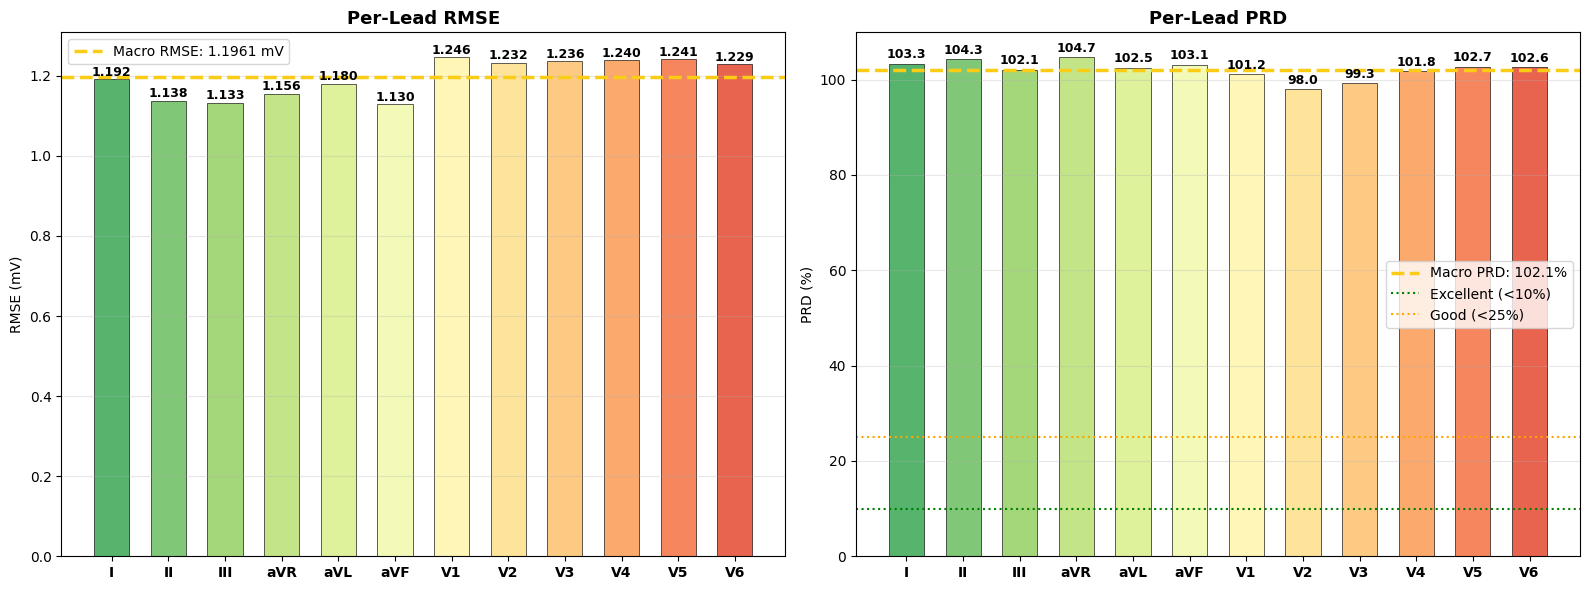

In [12]:
# CELL 11 — PER-LEAD RMSE + PRD
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, N_LEADS))

bars = axes[0].bar(np.arange(N_LEADS), rmse_per_lead, width=0.62,
                   color=colors, alpha=0.88, edgecolor='black', lw=0.5)
axes[0].axhline(rmse_macro, color='#facc15', ls='--', lw=2.5,
                label=f'Macro RMSE: {rmse_macro:.4f} mV')
for bar, val in zip(bars, rmse_per_lead):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_xticks(np.arange(N_LEADS)); axes[0].set_xticklabels(LEAD_NAMES, fontsize=10, fontweight='bold')
axes[0].set_ylabel('RMSE (mV)'); axes[0].set_title('Per-Lead RMSE', fontsize=13, fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3, axis='y')

bars2 = axes[1].bar(np.arange(N_LEADS), prd_per_lead, width=0.62,
                    color=colors, alpha=0.88, edgecolor='black', lw=0.5)
axes[1].axhline(prd_macro, color='#facc15', ls='--', lw=2.5, label=f'Macro PRD: {prd_macro:.1f}%')
axes[1].axhline(10, color='green',  ls=':', lw=1.5, label='Excellent (<10%)')
axes[1].axhline(25, color='orange', ls=':', lw=1.5, label='Good (<25%)')
for bar, val in zip(bars2, prd_per_lead):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f'{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_xticks(np.arange(N_LEADS)); axes[1].set_xticklabels(LEAD_NAMES, fontsize=10, fontweight='bold')
axes[1].set_ylabel('PRD (%)'); axes[1].set_title('Per-Lead PRD', fontsize=13, fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '02_per_lead_rmse_prd.png'), dpi=150, bbox_inches='tight')
plt.show()


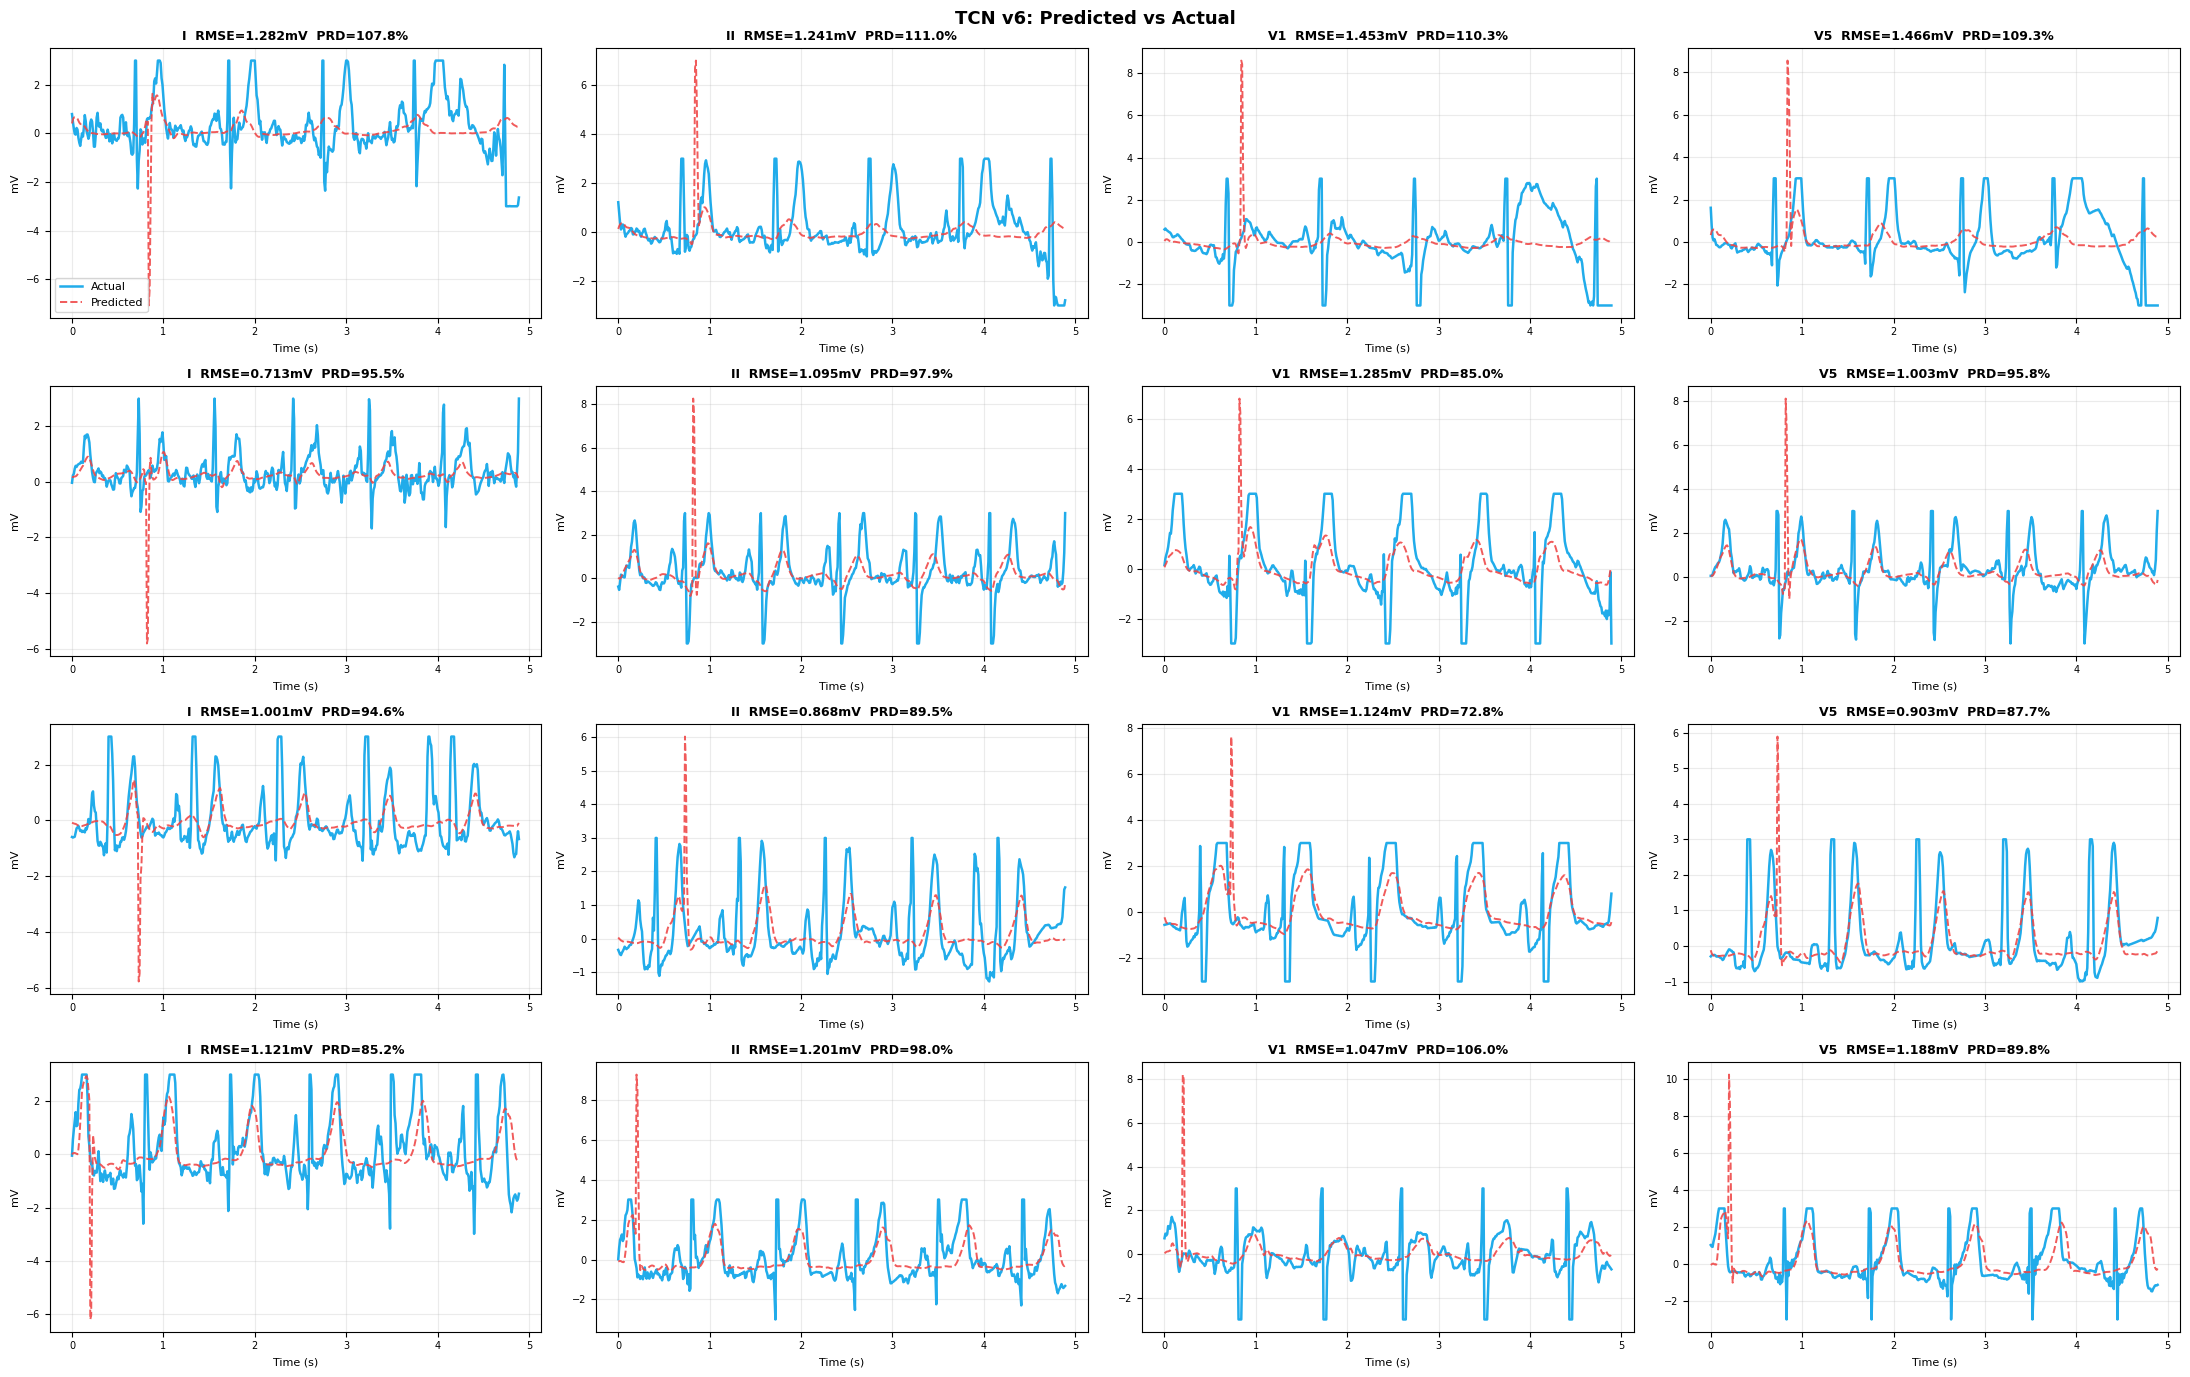

In [13]:
# CELL 12 — PREDICTION OVERLAY
N_ROWS       = 4
lead_indices = [LEAD_NAMES.index(l) if l in LEAD_NAMES else i
                for i, l in enumerate(['I', 'II', 'V1', 'V5'])][:4]
t_axis = np.arange(HORIZON) / FS

fig, axes = plt.subplots(N_ROWS, 4, figsize=(22, 14))
for row in range(N_ROWS):
    for col, li in enumerate(lead_indices):
        ax     = axes[row, col]
        actual = test_targets[row, :, li]
        pred   = test_preds[row,   :, li]
        rmse_i = np.sqrt(mean_squared_error(actual, pred))
        prd_i  = 100*np.sqrt(np.sum((actual-pred)**2)/(np.sum(actual**2)+1e-9))
        ax.plot(t_axis, actual, color='#0ea5e9', lw=1.8, label='Actual',    alpha=0.92)
        ax.plot(t_axis, pred,   color='#ef4444', lw=1.4, label='Predicted', alpha=0.88, ls='--')
        ax.set_title(f'{LEAD_NAMES[li]}  RMSE={rmse_i:.3f}mV  PRD={prd_i:.1f}%',
                     fontsize=9, fontweight='bold')
        ax.set_xlabel('Time (s)', fontsize=8); ax.set_ylabel('mV', fontsize=8)
        ax.tick_params(labelsize=7); ax.grid(True, alpha=0.25)
        if col == 0 and row == 0: ax.legend(fontsize=8)

fig.suptitle('TCN v6: Predicted vs Actual', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '03_predictions_overlay.png'), dpi=150, bbox_inches='tight')
plt.show()


In [14]:
# CELL 13 — QRS F1
TOL_SAMPLES = int(0.05 * FS)

def detect_peaks_ecg(sig, fs=FS):
    height = np.mean(sig) + 0.4 * np.std(sig)
    peaks, _ = find_peaks(sig, height=height, distance=int(0.25 * fs))
    return peaks

def qrs_precision_recall_f1(actual_arr, pred_arr, tol=TOL_SAMPLES):
    tp = fp = fn = 0
    for n in range(actual_arr.shape[0]):
        a_peaks = detect_peaks_ecg(actual_arr[n])
        p_peaks = detect_peaks_ecg(pred_arr[n])
        matched = set()
        for pp in p_peaks:
            if len(a_peaks) == 0: fp += 1; continue
            dists = np.abs(a_peaks - pp)
            best  = a_peaks[np.argmin(dists)]
            if dists.min() <= tol and best not in matched:
                matched.add(best); tp += 1
            else: fp += 1
        fn += len(a_peaks) - len(matched)
    prec = tp / (tp + fp + 1e-9)
    rec  = tp / (tp + fn + 1e-9)
    f1   = 2 * prec * rec / (prec + rec + 1e-9)
    return prec, rec, f1, tp, fp, fn

li   = LEAD_NAMES.index('II') if 'II' in LEAD_NAMES else 1
n_ev = min(300, test_targets.shape[0])
prec, rec, f1, tp, fp, fn = qrs_precision_recall_f1(
    test_targets[:n_ev, :, li], test_preds[:n_ev, :, li])

print(f'QRS on Lead {LEAD_NAMES[li]}  (n={n_ev}, tol=±50ms)')
print(f'  TP={tp}  FP={fp}  FN={fn}')
print(f'  Precision={prec:.3f}  Recall={rec:.3f}  F1={f1:.3f}')
if f1 < 0.3:   print('FAIL')
elif f1 < 0.5: print('Partial — extend training')
else:          print('Good — tracking R-peaks')


QRS on Lead II  (n=300, tol=±50ms)
  TP=567  FP=1039  FN=2593
  Precision=0.353  Recall=0.179  F1=0.238
FAIL


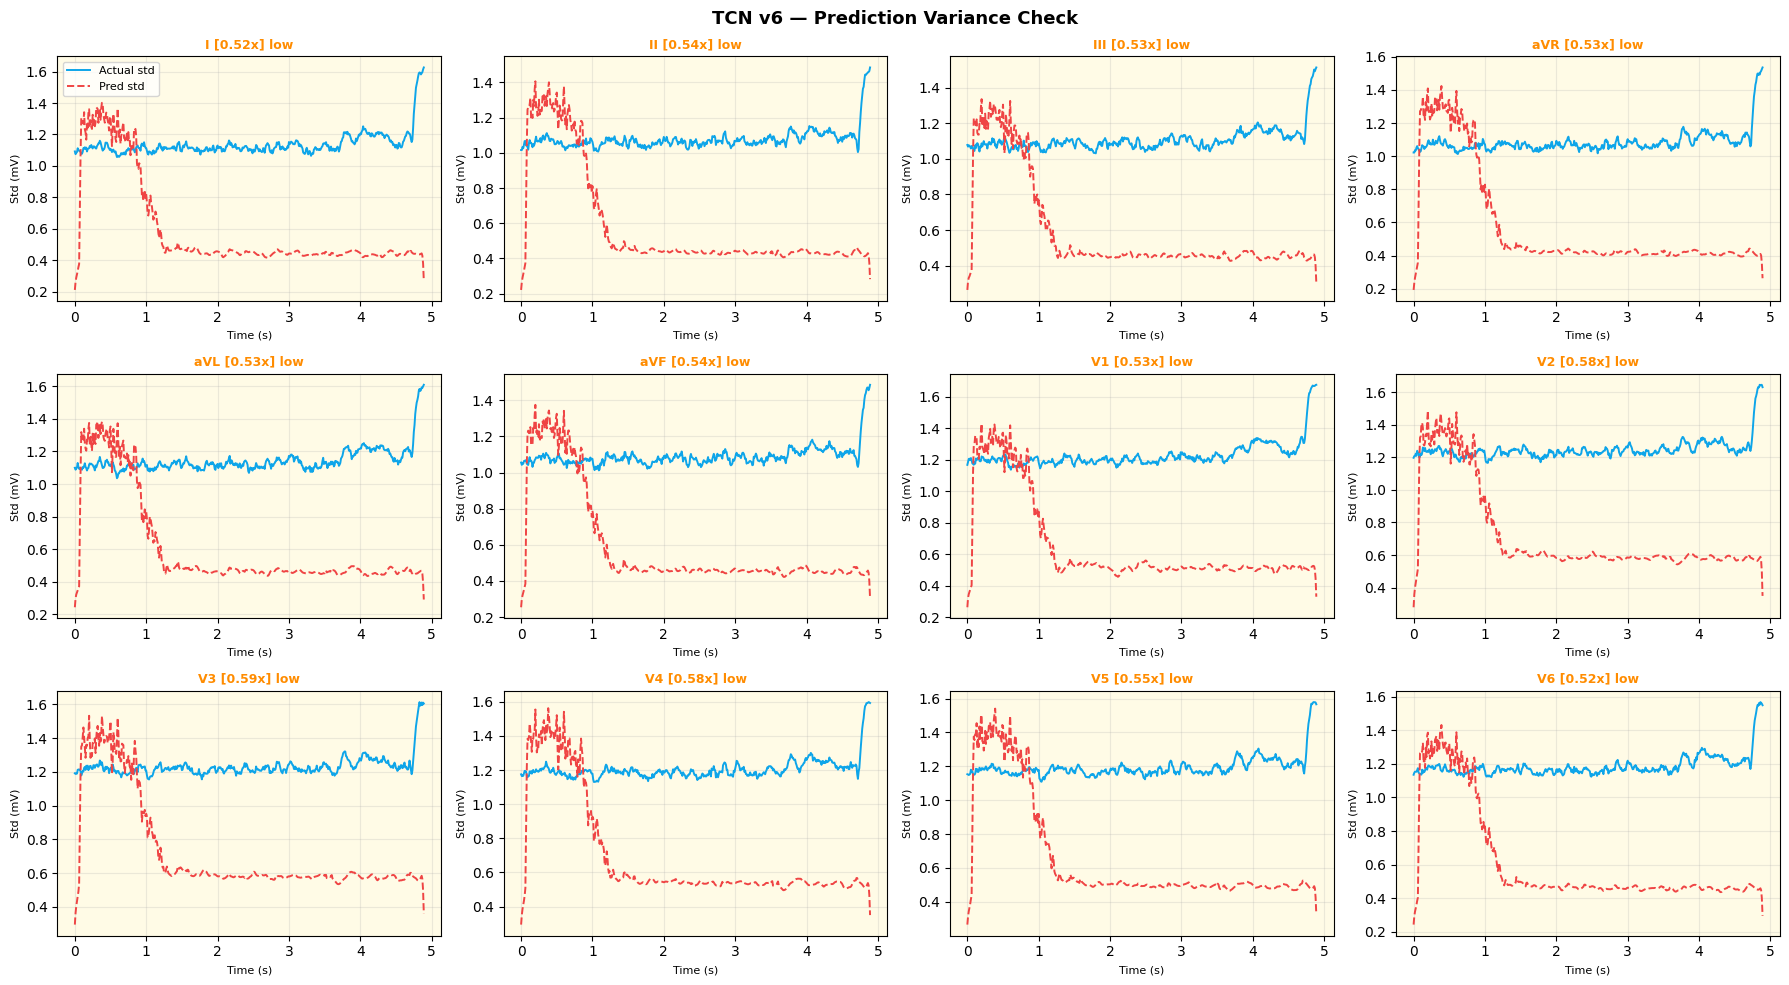

Low-variance: ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6'] — extend epochs or raise GRAD_WEIGHT to 0.7


In [15]:
# CELL 14 — VARIANCE CHECK
pred_std = test_preds.std(axis=0)
true_std = test_targets.std(axis=0)
t_axis   = np.arange(HORIZON) / FS

fig, axes = plt.subplots(3, 4, figsize=(18, 10))
flat_leads, low_leads = [], []
for i, (ax, name) in enumerate(zip(axes.flatten(), LEAD_NAMES)):
    ax.plot(t_axis, true_std[:,i], color='#0ea5e9', lw=1.4, label='Actual std')
    ax.plot(t_axis, pred_std[:,i], color='#ef4444', lw=1.4, label='Pred std', ls='--')
    ratio = pred_std[:,i].mean() / (true_std[:,i].mean() + 1e-9)
    ax.set_xlabel('Time (s)', fontsize=8); ax.set_ylabel('Std (mV)', fontsize=8)
    ax.grid(alpha=0.25)
    if i == 0: ax.legend(fontsize=8)
    if ratio < 0.3:
        ax.set_facecolor('#fff0f0')
        ax.set_title(f'{name} [{ratio:.2f}x] FLAT', color='red', fontweight='bold', fontsize=9)
        flat_leads.append(name)
    elif ratio < 0.6:
        ax.set_facecolor('#fffbe6')
        ax.set_title(f'{name} [{ratio:.2f}x] low', color='darkorange', fontweight='bold', fontsize=9)
        low_leads.append(name)
    else:
        ax.set_title(f'{name} [{ratio:.2f}x] OK', fontweight='bold', fontsize=9)

fig.suptitle('TCN v6 — Prediction Variance Check', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '04_variance_check.png'), dpi=150, bbox_inches='tight')
plt.show()

if flat_leads and len(flat_leads) == N_LEADS:
    print('ALL FLAT — check Cell 6 loss balance')
elif flat_leads:
    print(f'Flat: {flat_leads} — raise FFT_WEIGHT to 0.2 in Cell 6')
elif low_leads:
    print(f'Low-variance: {low_leads} — extend epochs or raise GRAD_WEIGHT to 0.7')
else:
    print(f'OK  overall ratio = {pred_std.mean()/true_std.mean():.2f}x')


In [16]:
# CELL 15 — SAVE RESULTS
results = dict(
    model='TCN_v6_fixed_loss_balance',
    horizon_s=HORIZON/FS, input_s=INPUT_LEN/FS,
    n_parameters=n_params,
    test_loss=float(test_loss),
    mae_per_lead=mae_per_lead, mae_macro=mae_macro,
    rmse_per_lead=rmse_per_lead, rmse_macro=rmse_macro,
    prd_per_lead=prd_per_lead, prd_macro=prd_macro,
    qrs_precision=float(prec), qrs_recall=float(rec), qrs_f1=float(f1),
    loss_config=dict(huber_delta=HUBER_DELTA, grad_weight=GRAD_WEIGHT,
                     fft_weight=FFT_WEIGHT, hf_boost=HF_BOOST, fft_normalized=True),
    norm=dict(mu=NORM_MU, sigma=NORM_SIGMA),
    history=history, lead_names=LEAD_NAMES,
    test_preds=test_preds, test_targets=test_targets,
)
res_path = os.path.join(CKPT_DIR, 'TCN_v6_results.pkl')
with open(res_path, 'wb') as f:
    pickle.dump(results, f)

avg_ep = np.mean(history['epoch_secs'])
print(f'\n{"="*64}')
print(f'  TCN v6 FINAL')
print(f'{"="*64}')
print(f'  Architecture : TCN Enc-Dec (K=5, 4 blocks, skip connections)')
print(f'  Loss         : Huber + {GRAD_WEIGHT}xGradL1 + {FFT_WEIGHT}xNormFFT  (GRAD fixed from 3.0)')
print(f'  Speed        : {avg_ep:.1f}s/epoch')
print(f'  Parameters   : {n_params:,}')
print(f'  Macro MAE    : {mae_macro:.6f} mV')
print(f'  Macro RMSE   : {rmse_macro:.6f} mV')
print(f'  Macro PRD    : {prd_macro:.2f}%')
print(f'  QRS F1       : {f1:.3f}')
print(f'{"="*64}')
print('OK TCN v6 complete')



  TCN v6 FINAL
  Architecture : TCN Enc-Dec (K=5, 4 blocks, skip connections)
  Loss         : Huber + 0.5xGradL1 + 0.1xNormFFT  (GRAD fixed from 3.0)
  Speed        : 26.9s/epoch
  Parameters   : 1,947,020
  Macro MAE    : 0.739848 mV
  Macro RMSE   : 1.196072 mV
  Macro PRD    : 102.13%
  QRS F1       : 0.238
OK TCN v6 complete
